In [1]:
import gym

In [2]:
reward_history  = []     
entropy_history = []     
step_index      = []    

def record_stats(avg_return: float, ent: float, step: int):
    reward_history.append(avg_return)
    entropy_history.append(ent)
    step_index.append(step)

def plot_reward_entropy(rewards, entropies, steps, title="Return vs Entropy"):
    import matplotlib.pyplot as plt
    import numpy as np

    steps = np.asarray(steps)
    fig, ax1 = plt.subplots()

    ax1.set_xlabel("Update")
    ax1.set_ylabel("Average return", color="tab:blue")
    ax1.plot(steps, rewards, color="tab:blue", label="Average return")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Entropy", color="tab:red")
    ax2.plot(steps, entropies, color="tab:red", label="Entropy")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right")

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [3]:
import time, os, logging, torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim, torch.multiprocessing as mp, numpy as np
import gymnasium as gym
from final.part_2_LunarLander_modules.compute_returns import compute_returns
from final.part_2_LunarLander_modules.worker import worker
from final.part_2_LunarLander_modules.ActorCritic import ActorCritic

learning_rate = 7e-4
gamma = 0.99
num_steps = 20
num_workers = max(1, mp.cpu_count() // 2)
max_updates = 200000
entropy_coef = 0.01
value_loss_coef = 0.5
max_grad_norm = 0.5
eval_interval = 5000
eval_episodes = 10
seed = 1
save_interval = 5000
log_interval = 100

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

mp.set_start_method("spawn", force=True)
torch.manual_seed(seed)
np.random.seed(seed)

env0 = gym.make("LunarLander-v3")
state_dim, action_dim = env0.observation_space.shape[0], env0.action_space.n
env0.close()

global_model = ActorCritic(state_dim, action_dim)
global_model.share_memory()
optimizer = optim.Adam(global_model.parameters(), lr=learning_rate, eps=1e-5)

exp_queue = mp.Queue()


In [14]:

for pid in range(num_workers):
    p = mp.Process(target=worker, args=(pid, exp_queue, global_model, num_steps))
    p.daemon = True
    p.start()
    logger.info(f"worker {pid} started")

start = time.time()

for update in range(1, max_updates + 1):
    S, A, R = [], [], []
    for _ in range(num_workers):
        s, a, r, d, last_v = exp_queue.get()
        G = compute_returns(r, d, last_v, global_model, gamma)
        S.extend(s); A.extend(a); R.extend(G)

    s_batch = torch.as_tensor(np.stack(S), dtype=torch.float32)
    a_batch = torch.as_tensor(A, dtype=torch.long)
    r_batch = torch.as_tensor(R, dtype=torch.float32)

    dist, values = global_model(s_batch)
    logp = dist.log_prob(a_batch)
    entropy = dist.entropy().mean()

    adv = r_batch - values.detach()
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    actor_loss = -(logp * adv).mean()
    critic_loss = value_loss_coef * F.mse_loss(values.squeeze(), r_batch)
    loss = actor_loss + critic_loss - entropy_coef * entropy

    optimizer.zero_grad()
    loss.backward()

    total_grad_norm = torch.nn.utils.clip_grad_norm_(global_model.parameters(), max_grad_norm)
    optimizer.step()

    if update % log_interval == 0:
        fps = (update * num_workers * num_steps) / (time.time() - start)
        reward_history.append(r_batch.mean())
        entropy_history.append(entropy.item())
        step_index.append(update)
        logger.info(
            f"upd {update:>6} | "
            f"loss {loss.item():+.3f} | "
            f"A {actor_loss.item():+.3f} | "
            f"C {critic_loss.item():+.3f} | "
            f"ent {entropy.item():.3f} | "
            f"adv μ {adv.mean().item():+.3f} σ {adv.std().item():.3f} | "
            f"grad {total_grad_norm:.3f} | "
            f"ret μ {r_batch.mean().item():+.1f} | "
            f"FPS {fps:,.0f}"
        )

    if update % save_interval == 0:
        torch.save(global_model.state_dict(), "a3_part_2_a2c_ENV1_ssaurav_asinha25.pth")
        logger.info("checkpoint saved")

    if update % eval_interval == 0:
        env = gym.make("LunarLander-v3")
        ep_scores = []
        for _ in range(eval_episodes):
            st = env.reset()[0]
            done, sc = False, 0.0
            while not done:
                with torch.no_grad():
                    dist, _ = global_model(torch.from_numpy(np.asarray(st, dtype=np.float32)).unsqueeze(0))
                act = dist.probs.argmax(dim=-1).item()
                step = env.step(act)
                if len(step) == 5:
                    st, r, term, trunc, _ = step
                    done = term or trunc
                else:
                    st, r, done, _ = step
                sc += r
            ep_scores.append(sc)
        logger.info(
            f"eval {update:>6} | "
            f"avg {np.mean(ep_scores):+.1f} | "
            f"min {np.min(ep_scores):+.1f} | "
            f"max {np.max(ep_scores):+.1f}"
        )

15:24:43 | INFO | worker 0 started
15:24:43 | INFO | worker 1 started
15:24:43 | INFO | worker 2 started
15:24:43 | INFO | worker 3 started
15:24:43 | INFO | worker 4 started
15:24:44 | INFO | upd    100 | loss +872.123 | A +0.021 | C +872.112 | ent 1.043 | adv μ -0.000 σ 1.000 | grad 390.052 | ret μ -60.5 | FPS 10,364
15:24:44 | INFO | upd    200 | loss +3870.453 | A +0.082 | C +3870.376 | ent 0.412 | adv μ -0.000 σ 1.000 | grad 1207.588 | ret μ -132.5 | FPS 16,122
15:24:44 | INFO | upd    300 | loss +3012.124 | A -0.042 | C +3012.172 | ent 0.644 | adv μ +0.000 σ 1.000 | grad 1015.281 | ret μ -140.2 | FPS 19,783
15:24:44 | INFO | upd    400 | loss +747.150 | A -0.050 | C +747.210 | ent 1.047 | adv μ -0.000 σ 1.000 | grad 375.698 | ret μ -119.6 | FPS 22,370
15:24:45 | INFO | upd    500 | loss +43.638 | A -0.056 | C +43.695 | ent 0.037 | adv μ -0.000 σ 1.000 | grad 93.098 | ret μ -96.9 | FPS 24,257
15:24:45 | INFO | upd    600 | loss +129.516 | A -0.061 | C +129.580 | ent 0.230 | adv μ 

KeyboardInterrupt: 

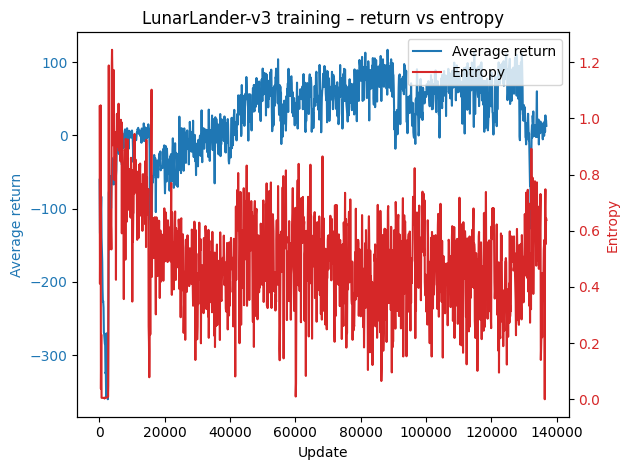

In [15]:
plot_reward_entropy(reward_history,
                    entropy_history,
                    step_index,
                    title="LunarLander-v3 training – return vs entropy")

In [4]:
import os, torch, numpy as np, matplotlib.pyplot as plt, gymnasium as gym

def evaluate(
    model_cls = ActorCritic,                    # e.g. ActorCritic
    weight_path   = "a3_part_2_a2c_ENV1_ssaurav_asinha25.pth",
    update        = 0,
    eval_episodes = 10,
    human_mode    = True,
    show_plot     = True,
    device        = "cpu",
):
    
    env_probe    = gym.make("LunarLander-v3")
    obs_dim      = env_probe.observation_space.shape[0]
    act_dim      = env_probe.action_space.n
    env_probe.close()

    model = model_cls(obs_dim, act_dim).to(device).eval()
    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print(f"[evaluate] loaded weights from {weight_path}")
    else:
        print(f"[evaluate] WARNING – weights not found at {weight_path}, using random params")

    env = gym.make(
        "LunarLander-v3",
        render_mode="human" if human_mode else None,
        continuous=False,
    )
    returns = []

    for ep in range(eval_episodes):
        state = env.reset()[0]
        done, ep_ret = False, 0.0
        while not done:
            with torch.no_grad():
                dist, _ = model(torch.from_numpy(state).unsqueeze(0).to(device))
            action = dist.probs.argmax(dim=-1).item()
            step   = env.step(action)
            if len(step) == 5:
                state, reward, term, trunc, _ = step
                done = term or trunc
            else:
                state, reward, done, _ = step
            ep_ret += reward
        returns.append(ep_ret)
        print(f"[evaluate] episode {ep+1}/{eval_episodes}  return={ep_ret:+.1f}")

    avg, std = float(np.mean(returns)), float(np.std(returns))
    print(f"[evaluate] update {update}  avg={avg:+.1f}  std={std:.1f}")

    if show_plot:
        plt.figure(figsize=(6,3))
        plt.plot(returns, marker='o')
        plt.axhline(avg, ls='--')
        plt.title(f"Evaluation at update {update}\nμ={avg:.1f}  σ={std:.1f}")
        plt.xlabel("Episode")
        plt.ylabel("Return")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return avg, std



[evaluate] loaded weights from a3_part_2_a2c_ENV1_ssaurav_asinha25.pth
[evaluate] episode 1/10  return=+245.1
[evaluate] episode 2/10  return=+138.2
[evaluate] episode 3/10  return=+236.1
[evaluate] episode 4/10  return=+98.2
[evaluate] episode 5/10  return=+219.3
[evaluate] episode 6/10  return=+100.3
[evaluate] episode 7/10  return=+131.5
[evaluate] episode 8/10  return=+232.6
[evaluate] episode 9/10  return=+138.3
[evaluate] episode 10/10  return=+125.6
[evaluate] update 0  avg=+166.5  std=56.3


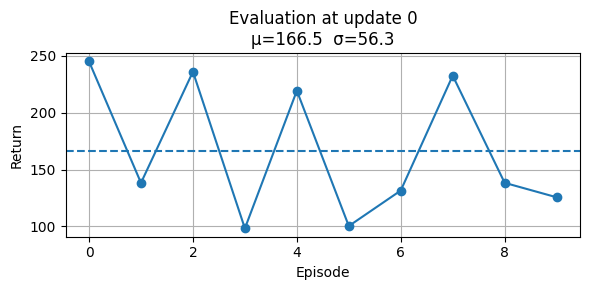

(166.52052662171366, 56.32175697506542)

In [6]:
env0 = gym.make("LunarLander-v3")
state_dim, action_dim = env0.observation_space.shape[0], env0.action_space.n
env0.close()

evaluate(model_cls = ActorCritic)